# Linear and Multiple Linear Regression

            ## 1. Learning objectives

            - Use scalars, vectors, matrices, dot products, mean, variance, and standard deviation
- Derive MSE gradients and implement gradient descent
- Evaluate multiple regression and L2 regularization

            ## 2. Prerequisites

            Basic Python, NumPy arrays, means, and the supervised-learning overview.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Predict a continuous target as a weighted combination of one or more features.

            ## 4. Real-world use cases

            - Price estimation
- Demand forecasting
- Interpretable effect-sized prediction baselines

            ## 5. Core intuition in simple language

            Fit a flat surface through the feature space so vertical residuals are collectively small.

## 6. Mathematical foundation

            $$\hat{\mathbf y}=\mathbf X\mathbf w+b,\qquad J(\mathbf w,b)=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2+\lambda\lVert\mathbf w\rVert_2^2.$$

            **Every symbol:**

            - $\mathbf X$ is the n-by-p feature matrix.
- $\mathbf w$ is a p-element weight vector.
- $b$ is scalar intercept.
- $\hat{\mathbf y}$ is prediction vector.
- $J$ is cost.
- $\lambda$ controls L2 regularization.
- $n$ is row count.

            **Why the equation is needed:** The matrix-vector dot product produces all predictions; MSE penalizes residuals and L2 discourages unstable large weights.

            **Small numerical example:** For x=[2,3], w=[4,-1], b=2, prediction=2(4)+3(-1)+2=7. If y=9, squared error is 4.

            **Connection to Python:** X @ weights + bias is prediction; 2*X.T@(prediction-y)/n is the weight gradient.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Define target and success metric
2. Split observations before fitted preprocessing
3. Build a simple baseline
4. Fit a transparent implementation
5. Fit the library estimator
6. Tune with validation evidence
7. Evaluate once on untouched test data

## 9. Implementation from scratch

A readable NumPy version exposes the mechanism and is checked against a tiny hand calculation.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
class LinearRegressionScratch:
    def __init__(self,learning_rate=.05,epochs=800,l2=0.0):
        self.learning_rate=learning_rate; self.epochs=epochs; self.l2=l2
    def fit(self,features,target):
        self.weights_=np.zeros(features.shape[1]); self.bias_=0.0; self.losses_=[]
        n=len(features)
        for _ in range(self.epochs):
            prediction=features@self.weights_+self.bias_
            error=prediction-target
            loss=np.mean(error**2)+self.l2*np.sum(self.weights_**2)
            gradient_w=2*features.T@error/n+2*self.l2*self.weights_
            gradient_b=2*error.mean()
            self.weights_-=self.learning_rate*gradient_w
            self.bias_-=self.learning_rate*gradient_b
            self.losses_.append(loss)
        return self
    def predict(self,features):
        return features@self.weights_+self.bias_

x_small=np.array([[1.],[2.]])
y_small=np.array([3.,5.])
model_small=LinearRegressionScratch(learning_rate=.05,epochs=1000).fit(x_small,y_small)
print("Tiny weight/bias:",model_small.weights_.round(3),round(model_small.bias_,3))

Tiny weight/bias: [2.] 1.0


## 10. Implementation using a standard library

Scikit-learn adds efficient numerical routines, validation, pipelines, and model-selection compatibility.

## 11. Dataset loading and exploration

The lesson uses a bundled or generated scikit-learn dataset with a fixed seed and no network access.

## 12. Data preprocessing

Train/validation/test roles are separated before scaling or other fitted transformations to prevent data leakage.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

,model,MAE,MSE,RMSE,R2
0,Mean baseline,76.457,9053.811,95.152,-0.044
1,NumPy gradient descent,14.406,334.633,18.293,0.961
2,scikit-learn,14.406,334.633,18.293,0.961


Feature matrix/vector shapes: (240, 3) (240,)
Scratch/library weights: [14.27 64.48 66.08] [14.27 64.48 66.08]


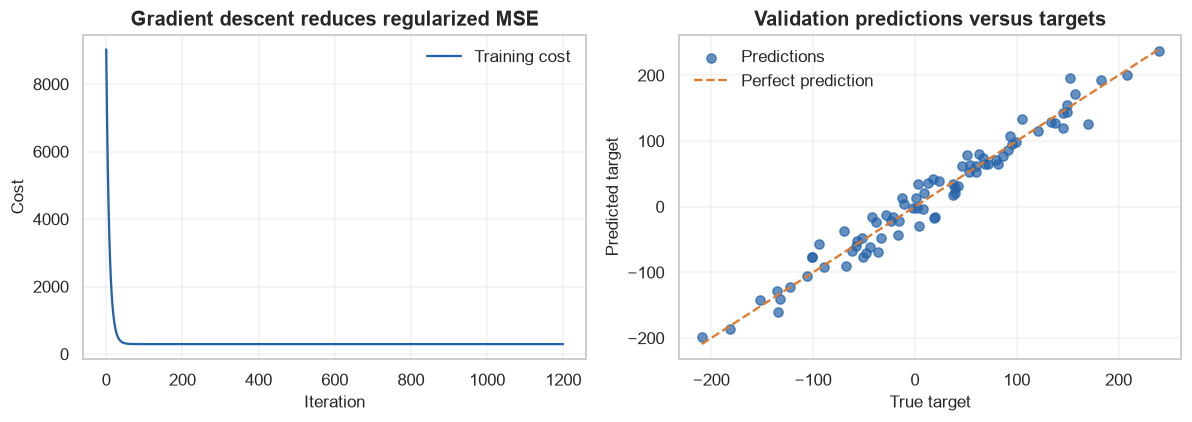

In [3]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X,y,truth=make_regression(n_samples=320,n_features=3,n_informative=3,noise=18,coef=True,random_state=RANDOM_SEED)
X_train,X_validation,y_train,y_validation=train_test_split(X,y,test_size=.25,random_state=RANDOM_SEED)
scaler=StandardScaler(); X_train_s=scaler.fit_transform(X_train); X_validation_s=scaler.transform(X_validation)
scratch=LinearRegressionScratch(learning_rate=.03,epochs=1200).fit(X_train_s,y_train)
library=LinearRegression().fit(X_train_s,y_train)
scratch_prediction=scratch.predict(X_validation_s); library_prediction=library.predict(X_validation_s)
rows=[]
for name,prediction in [("Mean baseline",np.full(len(y_validation),y_train.mean())),("NumPy gradient descent",scratch_prediction),("scikit-learn",library_prediction)]:
    rows.append({"model":name,"MAE":mean_absolute_error(y_validation,prediction),"MSE":mean_squared_error(y_validation,prediction),"RMSE":mean_squared_error(y_validation,prediction)**.5,"R2":r2_score(y_validation,prediction)})
comparison=pd.DataFrame(rows); display(comparison.round(3))
print("Feature matrix/vector shapes:",X_train_s.shape,y_train.shape)
print("Scratch/library weights:",scratch.weights_.round(2),library.coef_.round(2))
figure,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(scratch.losses_,color=COURSE_COLORS["blue"],label="Training cost"); axes[0].set(title="Gradient descent reduces regularized MSE",xlabel="Iteration",ylabel="Cost"); axes[0].legend()
axes[1].scatter(y_validation,library_prediction,alpha=.7,color=COURSE_COLORS["blue"],label="Predictions"); limits=[min(y_validation.min(),library_prediction.min()),max(y_validation.max(),library_prediction.max())]; axes[1].plot(limits,limits,linestyle="--",color=COURSE_COLORS["orange"],label="Perfect prediction")
axes[1].set(title="Validation predictions versus targets",xlabel="True target",ylabel="Predicted target"); axes[1].legend()
figure.tight_layout(); plt.show()

**How to interpret the result:** Scratch and library coefficients should be close. The diagonal plot reveals error spread; RMSE emphasizes large residuals while MAE is more robust.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Ridge alpha trades bias against variance. Stronger regularization shrinks weights and may first improve, then harm, validation error.

,alpha,validation_RMSE,coefficient_norm
0,0.001,18.293,93.423
1,0.006,18.293,93.421
2,0.032,18.292,93.411
3,0.178,18.285,93.353
4,1.000,18.254,93.031
5,5.623,18.190,91.258
6,31.623,20.469,82.442
7,177.828,43.112,53.549
8,1000.000,77.304,18.118


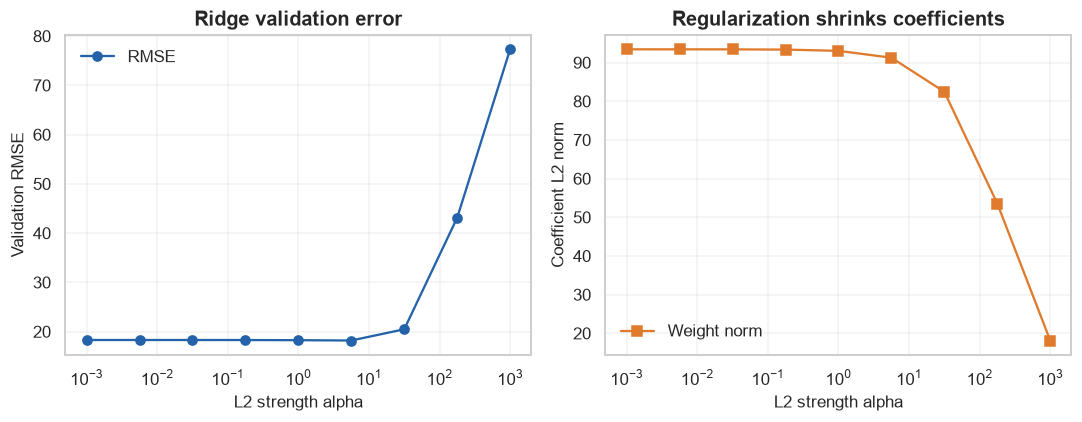

In [4]:
alphas=np.logspace(-3,3,9)
rows=[]
for alpha in alphas:
    candidate=Ridge(alpha=alpha).fit(X_train_s,y_train)
    rows.append({"alpha":alpha,"validation_RMSE":mean_squared_error(y_validation,candidate.predict(X_validation_s))**.5,"coefficient_norm":np.linalg.norm(candidate.coef_)})
ridge_results=pd.DataFrame(rows); display(ridge_results.round(3))
figure,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].semilogx(ridge_results["alpha"],ridge_results["validation_RMSE"],marker="o",color=COURSE_COLORS["blue"],label="RMSE"); axes[0].set(title="Ridge validation error",xlabel="L2 strength alpha",ylabel="Validation RMSE"); axes[0].legend()
axes[1].semilogx(ridge_results["alpha"],ridge_results["coefficient_norm"],marker="s",color=COURSE_COLORS["orange"],label="Weight norm"); axes[1].set(title="Regularization shrinks coefficients",xlabel="L2 strength alpha",ylabel="Coefficient L2 norm"); axes[1].legend()
figure.tight_layout(); plt.show()

## 18. Common mistakes

            - Fitting preprocessing before splitting
- Selecting hyperparameters on test data
- Reporting one metric without a baseline
- Confusing predictive association with causation

            ## 19. Advantages and disadvantages

            **Advantages**

            - Direct objective from labeled examples
- Clear held-out evaluation

            **Disadvantages**

            - Labels can be costly or biased
- Future data may differ from training data

            ## 20. When to use and when not to use the algorithm

            **Use it when:** a trustworthy target represents the decision and representative labeled examples are available.

            **Do not use it when:** labels do not represent the desired outcome or the goal is causal intervention rather than prediction.

## 21. Exercises

1. **Conceptual:** Why must features be arranged as an n-by-p matrix?
2. **Mathematical/hand calculation:** For y=[2,4] and predictions [3,1], compute MAE, MSE, and RMSE.
3. **Coding/experimentation:** Add a redundant correlated feature and compare unregularized versus Ridge coefficient stability.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Rows represent observations and columns features, making Xw one prediction per row.
2. Absolute errors [1,3] give MAE=2; squared errors [1,9] give MSE=5 and RMSE=sqrt(5)=2.236.
3. Duplicate a column with small noise, refit both models, and compare coefficient norms plus validation RMSE; Ridge usually distributes and shrinks weights more stably.

</details>

## 23. Summary and key takeaways

            - Data splitting and preprocessing are part of the model
- Scratch code explains the mechanism while the library version supports realistic use
- Metrics must match error costs
- Generalization—not memorization—is the objective

            ## 24. Further reading

            - [scikit-learn supervised learning guide](https://scikit-learn.org/stable/supervised_learning.html)
- [scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)